# **NLP part B : https://www.kaggle.com/datasets/aunanya875/suicidal-tweet-detection-dataset **

## **Step 1: Import Libraries**

In [ ]:
# Import Libraries
!pip install --upgrade patsy
!pip install -q transformers
!pip install --upgrade statsmodels
!pip install --upgrade seaborn
!pip install wordcloud
!pip install textblob
from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter
from scipy.sparse import hstack

# Import nltk here
import nltk

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')


# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# NLP
import re
import string

# import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

# Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.tokenize import word_tokenize
# ML Models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
# Deep Learning (DL models)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical

# Transformers (for DistilBERT or BERT)
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

# System
import warnings
warnings.filterwarnings('ignore')

# Download NLTK Resources for preprocessing
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


True

## **Step 2: Load Dataset and Perform EDA**

In [ ]:
# Load Suicide Ideation Dataset
df = pd.read_csv('/content/Suicide_Ideation_Dataset(Twitter-based).csv')

# Basic shape and column info
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Display first 5 records
df.head()

Dataset loaded successfully!
Shape: (1787, 2)
Columns: ['Tweet', 'Suicide']


,Tweet,Suicide
0,making some lunch,Not Suicide post
1,@Alexia You want his money.,Not Suicide post
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post
3,@jnaylor #kiwitweets Hey Jer! Since when did y...,Not Suicide post
4,Trying out &quot;Delicious Library 2&quot; wit...,Not Suicide post


**Dataset Overview (Shape, columnsNAme, Datatype, CheckMissingValues)**

In [ ]:
# Dataset Overview
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nNull values:\n", df.isnull().sum())
print("\nUnique labels:\n", df['Suicide'].value_counts())

Dataset shape: (1787, 2)

Columns: ['Tweet', 'Suicide']

Data types:
 Tweet      object
Suicide    object
dtype: object

Null values:
 Tweet      2
Suicide    0
dtype: int64

Unique labels:
 Suicide
Not Suicide post           1127
Potential Suicide post      660
Name: count, dtype: int64


**Class Distribution Plot**

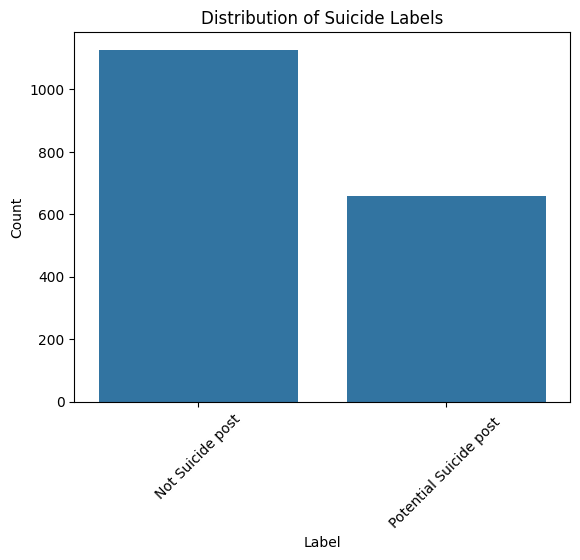

In [ ]:
# Label distribution plot
sns.countplot(data=df, x='Suicide')
plt.title('Distribution of Suicide Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Class distribution in percentage**

Class distribution (%):
Suicide
Not Suicide post           63.066592
Potential Suicide post     36.933408
Name: proportion, dtype: float64


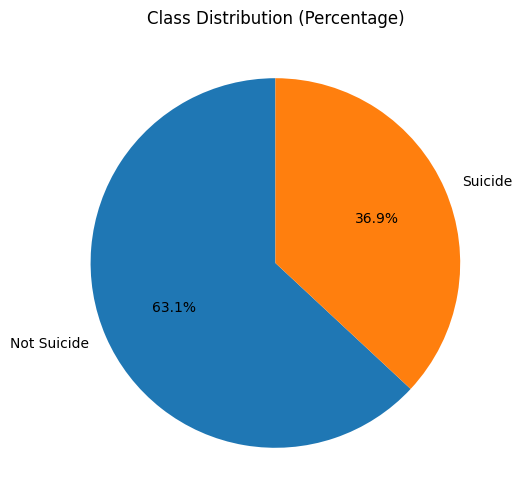

In [ ]:
# Class distribution in percentage
percentages = df['Suicide'].value_counts(normalize=True) * 100
print("Class distribution (%):")
print(percentages)

# Pie chart
percentages.plot.pie(autopct='%1.1f%%', labels=['Not Suicide', 'Suicide'], startangle=90, figsize=(6,6))
plt.title("Class Distribution (Percentage)")
plt.ylabel("")
plt.show()

**Tweet Lengths**

In [ ]:
# Clean the Tweet column: drop rows with non-string (e.g., NaN or float)
df = df[df['Tweet'].apply(lambda x: isinstance(x, str))]

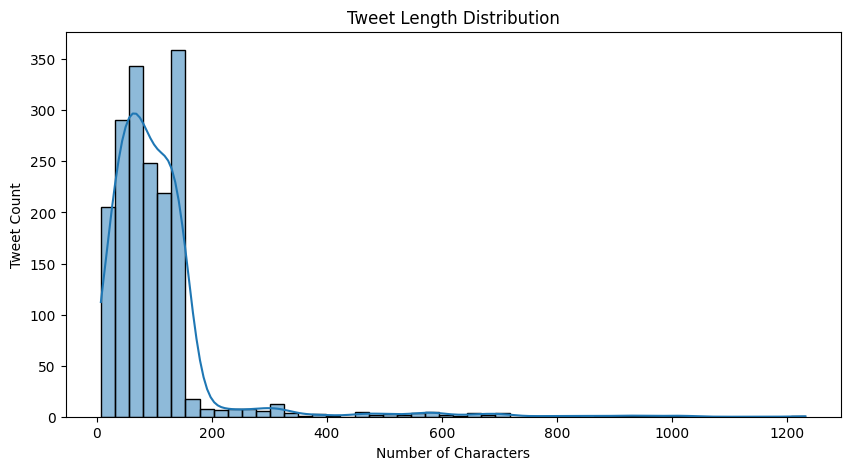

In [ ]:
# Add a new column for text length
df['text_length'] = df['Tweet'].apply(len)

# Distribution of tweet lengths
plt.figure(figsize=(10,5))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title('Tweet Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Tweet Count')
plt.show()

**Tweet Length by Class**

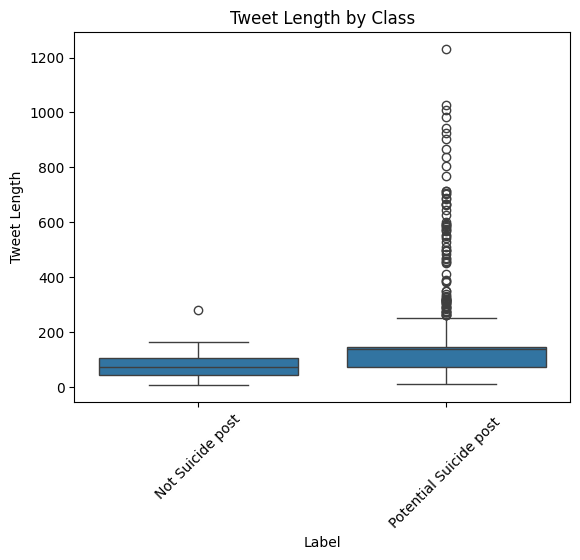

In [ ]:
sns.boxplot(x='Suicide', y='text_length', data=df)
plt.title("Tweet Length by Class")
plt.xlabel("Label")
plt.ylabel("Tweet Length")
plt.xticks(rotation=45)
plt.show()

**Number of Words per Tweet**

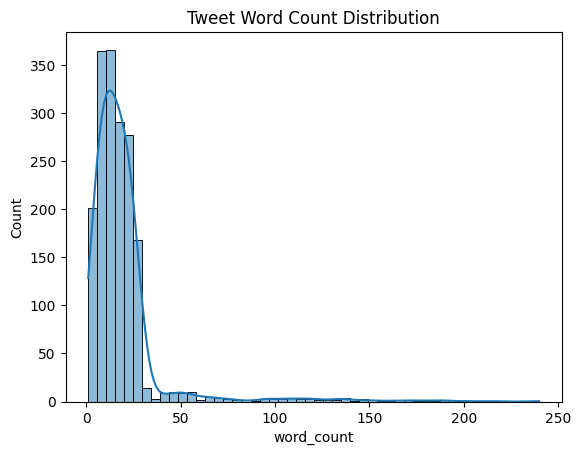

In [ ]:
df['word_count'] = df['Tweet'].apply(lambda x: len(x.split()))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Tweet Word Count Distribution")
plt.show()

**Hashtags and Mentions**

In [ ]:
df['has_hashtag'] = df['Tweet'].apply(lambda x: '#' in x)
df['has_mention'] = df['Tweet'].apply(lambda x: '@' in x)

print(df.groupby('Suicide')[['has_hashtag', 'has_mention']].mean())

                         has_hashtag  has_mention
Suicide                                          
Not Suicide post            0.039964     0.581705
Potential Suicide post      0.028832     0.329287


**Sentiment Analysis**

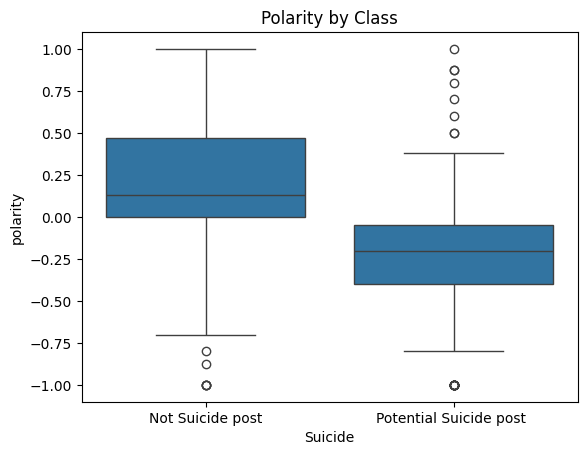

In [ ]:
df['polarity'] = df['Tweet'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['subjectivity'] = df['Tweet'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

sns.boxplot(x='Suicide', y='polarity', data=df)
plt.title("Polarity by Class")
plt.show()

**Word Cloud**

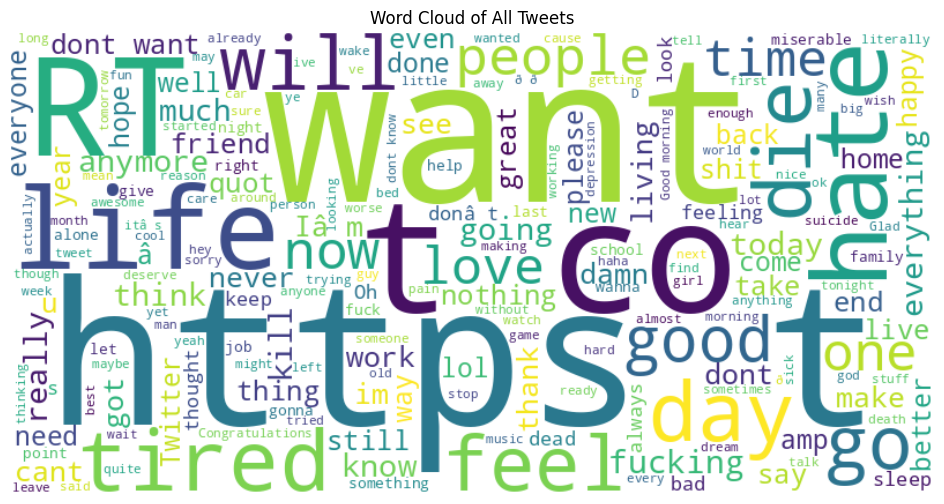

In [ ]:
# Generate WordCloud for all tweets
all_words = ' '.join(df['Tweet'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of All Tweets")
plt.show()

**Most Frequent Words by Class**

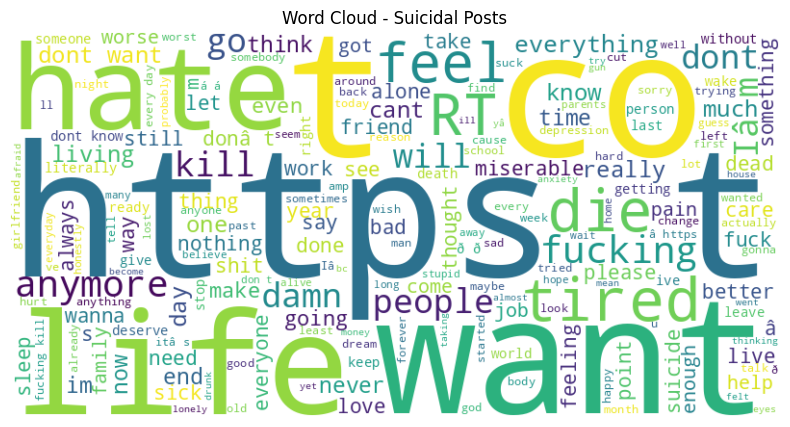

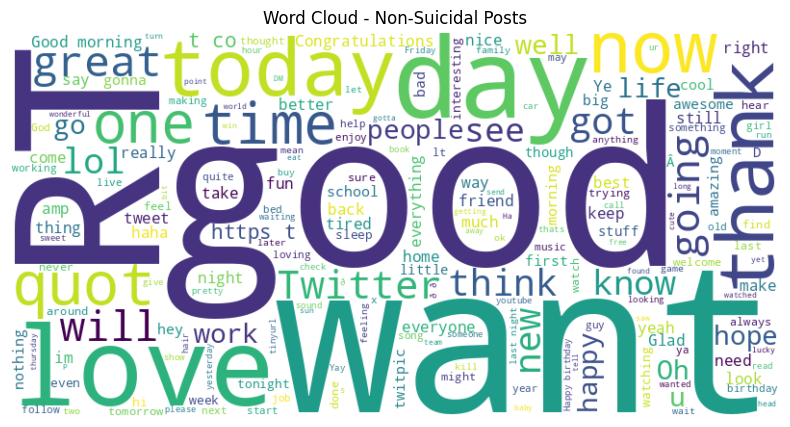

In [ ]:
# Normalize label values
df['Suicide'] = df['Suicide'].str.strip()

# Drop null tweets (if any)
df = df[df['Tweet'].notnull()]

# Create text blobs for each class
suicide_words = ' '.join(df[df['Suicide'] == 'Potential Suicide post']['Tweet'])
nonsuicide_words = ' '.join(df[df['Suicide'] == 'Not Suicide post']['Tweet'])

# Generate and display word clouds
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Suicidal posts
wc1 = WordCloud(width=800, height=400, background_color='white').generate(suicide_words)
plt.figure(figsize=(10, 5))
plt.imshow(wc1, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Suicidal Posts")
plt.show()

# Non-suicidal posts
wc2 = WordCloud(width=800, height=400, background_color='white').generate(nonsuicide_words)
plt.figure(figsize=(10, 5))
plt.imshow(wc2, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Non-Suicidal Posts")
plt.show()

**Top Frequent Words**

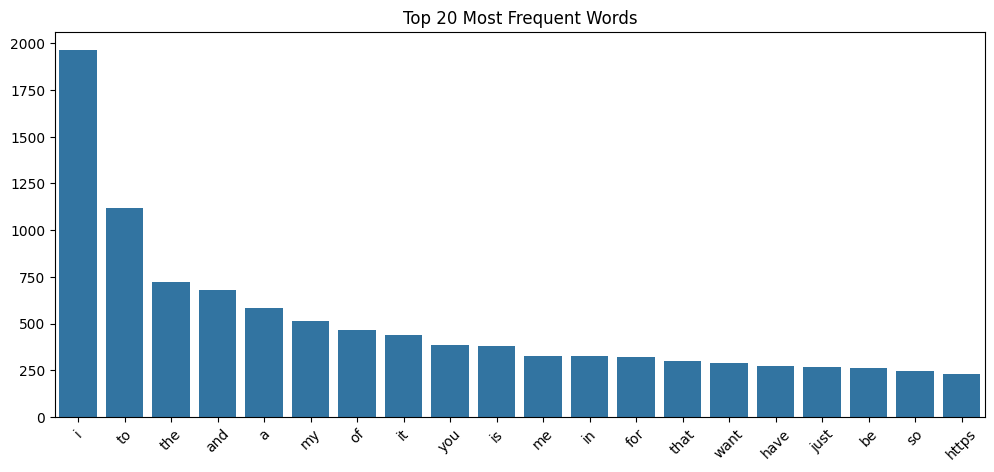

In [ ]:
# Tokenize and clean all tweets
def tokenize(tweet):
    return [w.lower() for w in word_tokenize(tweet) if w.isalpha()]

all_tokens = []
df['Tweet'].apply(lambda x: all_tokens.extend(tokenize(x)))

# Get 20 most common
word_freq = Counter(all_tokens).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(12,5))
sns.barplot(x=list(words), y=list(freqs))
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

**Duplicate Detection**

In [ ]:
# Check for completely duplicated rows
print("Total duplicate rows (all columns):", df.duplicated().sum())
# Check for duplicates based only on the 'Tweet' column
print("Duplicate tweets based on 'Tweet' content:", df.duplicated(subset='Tweet').sum())
# Show duplicate tweet examples
df[df.duplicated(subset='Tweet', keep=False)].sort_values('Tweet').head()

Total duplicate rows (all columns): 8
Duplicate tweets based on 'Tweet' content: 8


,Tweet,Suicide,text_length,word_count,has_hashtag,has_mention,polarity,subjectivity
1040,@jessedonoe I mean.... my life is miserable so...,Potential Suicide post,85,17,False,True,-0.304167,0.795833
1458,@jessedonoe I mean.... my life is miserable so...,Potential Suicide post,85,17,False,True,-0.304167,0.795833
951,AFTER EFFECTS HAS FROZEN AND I DID NOT I REPEA...,Potential Suicide post,141,26,False,False,-0.600000,0.800000
1173,AFTER EFFECTS HAS FROZEN AND I DID NOT I REPEA...,Potential Suicide post,141,26,False,False,-0.600000,0.800000
223,Became as hot as the persistent days resting h...,Potential Suicide post,69,12,False,False,-0.075000,0.775000


**Profane Word Detection**

In [ ]:
# Example list of profane words
profanity_list = ['fuck', 'shit', 'bitch', 'damn', 'asshole', 'dick', 'bastard', 'crap', 'pussy']
profane_words = set(profanity_list)

# Function to check for profanity
def contains_profanity(text):
    return any(word in profane_words for word in str(text).lower().split())

# Create a column for detection purpose
df['has_profanity'] = df['Tweet'].apply(contains_profanity)

# Count and show
print("Tweets containing profanity:", df['has_profanity'].sum())

# Preview examples
df[df['has_profanity'] == True].head()

Tweets containing profanity: 117


,Tweet,Suicide,text_length,word_count,has_hashtag,has_mention,polarity,subjectivity,has_profanity
2,@dizzyhrvy that crap took me forever to put to...,Potential Suicide post,86,16,False,True,-0.800000,0.800000,True
55,u - understand what the fuck im doing wrong wi...,Potential Suicide post,56,12,False,False,-0.450000,0.750000,True
65,"@Farbelowaverag1,,And I just dont want to fuck...",Potential Suicide post,229,43,False,True,-0.500000,0.700000,True
71,I damn near hate smoking by myself but sometim...,Potential Suicide post,120,24,False,False,-0.233333,0.433333,True
84,My whole family is so damn beautiful and Iâm...,Potential Suicide post,142,29,False,False,-0.050000,0.700000,True


## **Step 3: Data Preprocessing**

In [ ]:
# Initial Cleanup
df = df[['Tweet', 'Suicide']].copy()
df = df.rename(columns={'Tweet': 'text', 'Suicide': 'label_raw'})
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']

# Label Encoding
df['label'] = df['label_raw'].map({'Not Suicide post': 0, 'Potential Suicide post': 1})

# Text Cleaning Function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www.\S+", '', text)
    text = re.sub(r"@\w+|#\w+", '', text)
    text = re.sub(r"[^a-z\s]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return ' '.join(words)

# Apply Cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Remove empty or duplicate entries
df = df[df['clean_text'].str.strip() != '']
df = df.drop_duplicates(subset='clean_text')

# Add text length and word count for tracking
df['text_length'] = df['clean_text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

# Profanity Detection
profanity_list = ['fuck', 'shit', 'bitch', 'damn', 'kill', 'asshole']
df['has_profanity'] = df['clean_text'].apply(lambda x: any(word in x for word in profanity_list))

# Handle Class Imbalance
class_0 = df[df['label'] == 0]
class_1 = df[df['label'] == 1]

if len(class_0) != len(class_1):
    minority = class_1 if len(class_1) < len(class_0) else class_0
    majority = class_0 if len(class_0) > len(class_1) else class_1
    minority_upsampled = resample(minority,
                                  replace=True,
                                  n_samples=len(majority),
                                  random_state=42)
    df = pd.concat([majority, minority_upsampled])

# Final Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Final Output
print(" Final Preprocessing Complete!")
print("Shape:", df.shape)
print("Class Distribution:\n", df['label'].value_counts())
display(df[['text', 'clean_text', 'label', 'has_profanity', 'text_length', 'word_count']].head())

 Final Preprocessing Complete!
Shape: (2166, 7)
Class Distribution:
 label
1    1083
0    1083
Name: count, dtype: int64


,text,clean_text,label,has_profanity,text_length,word_count
0,You hear this @DaveOshry? Together we could st...,hear together could start sort terrible busine...,1,False,68,11
1,"@sanguivori,kaycee!!â¡ glenn!!â¡,i dont want...",kaycee glenni dont want anymore wish dead,1,False,41,7
2,"@saraayk5,,RT @jaemverse: i just dont want to ...",rt dont want anymore,1,False,20,4
3,@sh_tbritttsays *que screamo voice* SO CUT MY ...,que screamo voice cut wrist black eye,1,False,37,7
4,RT @milatorres170: I never had to do the most ...,rt never throw shade hate quiet bitch still wa...,1,True,69,13


**Post-Preprocessing EDA**

In [ ]:
def validate_post_preprocessing(df):

    print("\n Validating Post-Preprocessing")

    # Null & Empty Checks
    null_count = df['clean_text'].isnull().sum()
    empty_count = (df['clean_text'].str.strip() == '').sum()
    print(f"  Null 'clean_text' rows: {null_count}")
    print(f"  Empty 'clean_text' rows: {empty_count}")

    # Class Distribution
    class_dist = df['label'].value_counts(normalize=False).sort_index()
    class_percent = df['label'].value_counts(normalize=True).sort_index() * 100
    class_summary = pd.concat([class_dist, class_percent], axis=1)
    class_summary.columns = ['count', 'percent']
    print("\n  Class Distribution (%):")
    print(class_summary)

    # Class Distribution Plot
    plt.figure(figsize=(6, 5))
    sns.countplot(data=df, x='label')
    plt.xticks([0, 1], ['Not Suicide', 'Suicide'])
    plt.title('Class Distribution After Preprocessing')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.show()

    # Duplicate Check
    dup_count = df.duplicated(subset='clean_text').sum()
    print(f"\n Duplicate rows (by 'clean_text'): {dup_count}")

    # Tweet Length & Word Count Distributions
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(df['text_length'], bins=30, kde=True, ax=axes[0])
    axes[0].set_title('Tweet Length Distribution (Characters)')
    axes[0].set_xlabel('Length')

    sns.histplot(df['word_count'], bins=30, kde=True, ax=axes[1])
    axes[1].set_title('Tweet Word Count Distribution')
    axes[1].set_xlabel('Words per Tweet')
    plt.tight_layout()
    plt.show()

    # Boxplot by class
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x='label', y='text_length')
    plt.xticks([0, 1], ['Not Suicide', 'Suicide'])
    plt.title('Text Length by Class')
    plt.xlabel('label')
    plt.ylabel('text_length')
    plt.show()

    # Sample Clean vs Original
    print("\n Sample of original vs cleaned text:")
    display(df[['text', 'clean_text']].sample(5))

    # Profanity Check
    if 'has_profanity' in df.columns:
        profane = df[df['has_profanity']]
        print(f"\n Tweets flagged with profanity: {len(profane)}")
        display(profane[['clean_text']].head(5))


 Validating Post-Preprocessing
  Null 'clean_text' rows: 0
  Empty 'clean_text' rows: 0

  Class Distribution (%):
       count  percent
label                
0       1083     50.0
1       1083     50.0


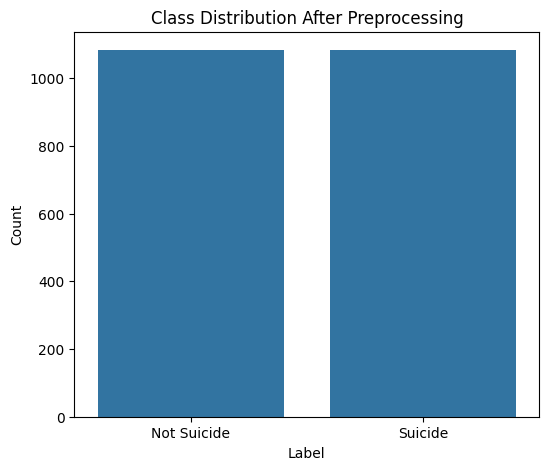


 Duplicate rows (by 'clean_text'): 572


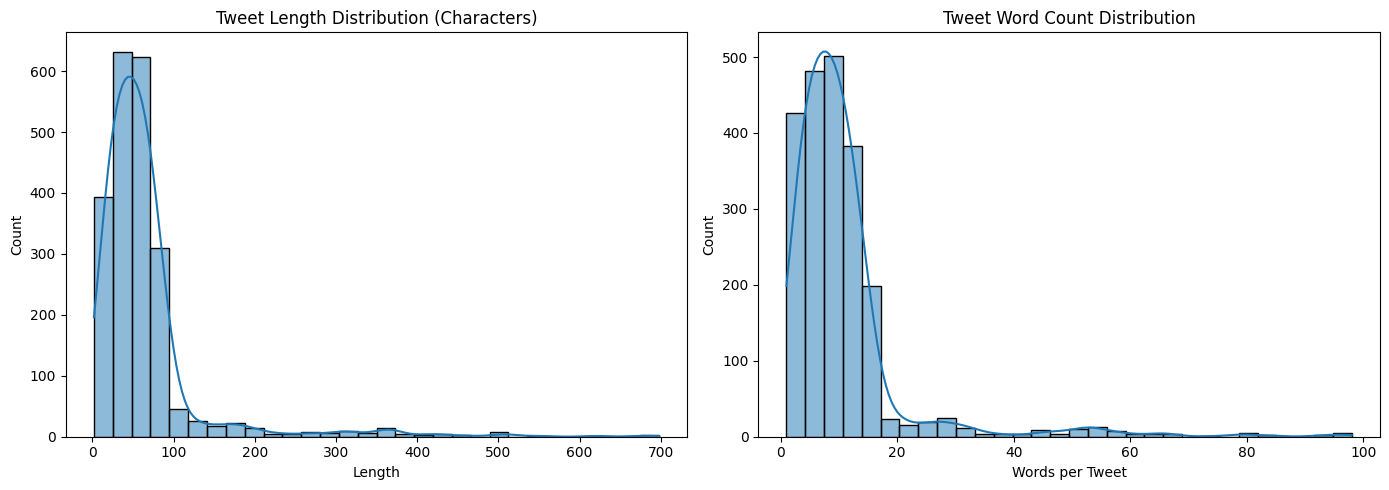

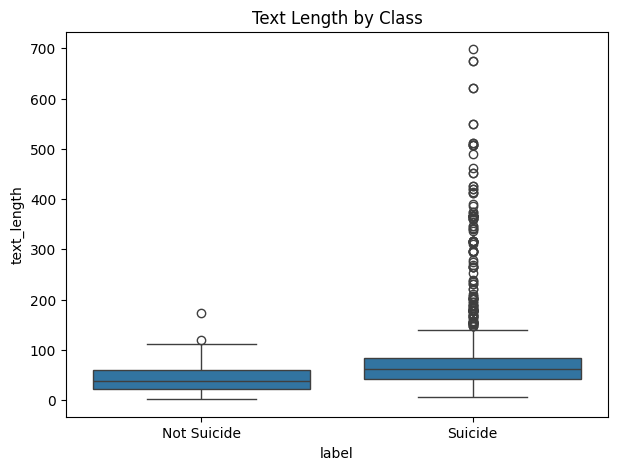


 Sample of original vs cleaned text:


,text,clean_text
469,I know I canât get all the things i want in ...,know cant get thing want life get feel like le...
937,@dizzyhrvy that crap took me forever to put to...,crap took forever put together im going go sle...
1422,thanks for the photo @basibanget,thanks photo
1543,my morning started out so bad i just want to g...,morning started bad want go home sleep forever
188,everyone follow kade,everyone follow kade



 Tweets flagged with profanity: 411


,clean_text
4,rt never throw shade hate quiet bitch still wa...
5,correct one absolutely want live country fucki...
9,correct one absolutely want live country fucki...
19,damn really hate
21,school worst get nervous worked throw pas forc...


In [ ]:
validate_post_preprocessing(df)

## **Step 4: Feature Engineering & Transformation**

In [ ]:
# Text Vectorization (TF-IDF on raw cleaned text)
print(" Applying TF-IDF Vectorization...")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df['clean_text'])

# Feature Engineering (text length, word count, profanity)
print(" Adding Engineered Features...")
extra_features = df[['text_length', 'word_count', 'has_profanity']].copy()

# Convert boolean to int
if extra_features['has_profanity'].dtype == 'bool':
    extra_features['has_profanity'] = extra_features['has_profanity'].astype(int)

# Normalize engineered features
scaler = MinMaxScaler()
extra_scaled = scaler.fit_transform(extra_features)

# Combining TF-IDF and Engineered Features
X_final = hstack([X_tfidf, extra_scaled])

# Target Variable
y_final = df['label'].values

print(" Feature Engineering and Transformation Complete")
print(" Final Input Shape:", X_final.shape)

 Applying TF-IDF Vectorization...
 Adding Engineered Features...
 Feature Engineering and Transformation Complete
 Final Input Shape: (2166, 5003)


## **Step 5: Model Bulding**

### **1- Random Forest (model_rf1)**

**Baseline RF**


Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.96       217
           1       0.97      0.94      0.96       217

    accuracy                           0.96       434
   macro avg       0.96      0.96      0.96       434
weighted avg       0.96      0.96      0.96       434



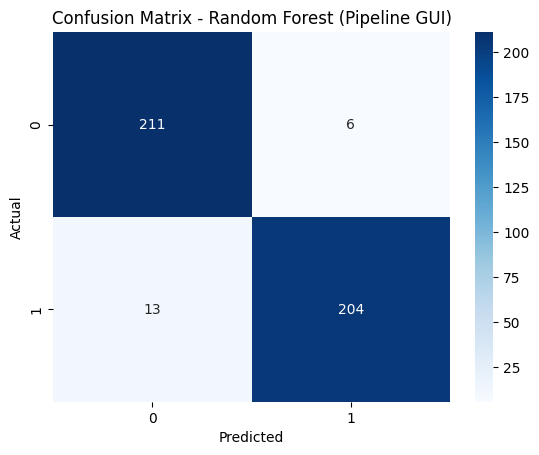

 Model 1 .


In [ ]:
# Random Forest (Baseline)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# clean tweet text and binary labels
X = df['clean_text']
y = df['label']

#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

#  Build pipeline (TF-IDF + Random Forest)
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

#  Train model
start = time.time()
pipeline_rf.fit(X_train, y_train)
end = time.time()
train_time = round(end - start, 2)

# Predict and evaluate
y_pred = pipeline_rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Pipeline GUI)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save the model
with open("model1_rf_pipeline.pkl", "wb") as file:
    pickle.dump(pipeline_rf, file)

# Save training results
results_df = pd.DataFrame({
    "Model": ["RandomForest_Baseline_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model1_rf_pipeline_results.csv", index=False)

print(" Model 1 .")


**Hyperparameter Tuning for random forest**

In [ ]:
# Random Forest (Tuned)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# clean tweet text and binary labels
X = df['clean_text']
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Pipeline with TF-IDF + Random Forest
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', RandomForestClassifier(random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

# Grid Search CV
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', verbose=1, n_jobs=-1)

#Train
start = time.time()
grid.fit(X_train, y_train)
end = time.time()
train_time = round(end - start, 2)

best_model = grid.best_estimator_
print(" Best Parameters Found:\n", grid.best_params_)

# Evaluate
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Tuned Pipeline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save best pipeline
with open("model2_rf_tuned_pipeline.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save results
results_df = pd.DataFrame({
    "Model": ["RandomForest_Tuned_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model2_rf_tuned_pipeline_results.csv", index=False)

print(" Model 2 ")

Fitting 3 folds for each of 24 candidates, totalling 72 fits


### **2- Logistic Regression**

**Baseline Logistic Regression**

In [ ]:
# Logistic Regression (Baseline)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# clean text and binary labels
X = df['clean_text']
y = df['label']

#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

#  Build pipeline
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
start = time.time()
pipeline_lr.fit(X_train, y_train)
end = time.time()
train_time = round(end - start, 2)

# Predict and evaluate
y_pred = pipeline_lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Pipeline GUI)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#  Save pipeline
with open("model3_lr_pipeline.pkl", "wb") as file:
    pickle.dump(pipeline_lr, file)

# Save training results
results_df = pd.DataFrame({
    "Model": ["LogisticRegression_Baseline_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model3_lr_pipeline_results.csv", index=False)

print(" Model 3 ")

**Tuned Logistic Regression**

In [ ]:
# Logistic Regression (Tuned)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Input
X = df['clean_text']
y = df['label']

#  Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Define pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs']
}

# Grid Search
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)

# Train
start = time.time()
grid.fit(X_train, y_train)
end = time.time()
train_time = round(end - start, 2)

best_model = grid.best_estimator_
print(" Best Parameters Found:\n", grid.best_params_)

# Predict and Evaluate
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Tuned Pipeline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
with open("model4_lr_tuned_pipeline.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save results
results_df = pd.DataFrame({
    "Model": ["LogisticRegression_Tuned_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model4_lr_tuned_pipeline_results.csv", index=False)

print(" Model 4 ")

### **3- Naïve Bayes Classifier (MultinomialNB)**

**Baseline Naive Bayes**

In [ ]:
# Naïve Bayes (Baseline)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Input
X = df['clean_text']
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Pipeline with TF-IDF + Naïve Bayes
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', MultinomialNB())
])

# Train
start = time.time()
pipeline_nb.fit(X_train, y_train)
end = time.time()
train_time = round(end - start, 2)

# Predict and evaluate
y_pred = pipeline_nb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naïve Bayes (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
with open("model5_nb_pipeline.pkl", "wb") as file:
    pickle.dump(pipeline_nb, file)

#  Save results
results_df = pd.DataFrame({
    "Model": ["NaiveBayes_Baseline_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model5_nb_pipeline_results.csv", index=False)

print(" Model 5 (Naïve Bayes) trained, saved, and GUI-ready.")

**Tuned Naïve Bayes**

In [ ]:
# Naïve Bayes (Tuned)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Input
X = df['clean_text']
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Build pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', MultinomialNB())
])

# GridSearch hyperparameter tuning
param_grid = {
    'clf__alpha': [0.1, 0.5, 1.0, 2.0]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)

# Train
start = time.time()
grid.fit(X_train, y_train)
end = time.time()
train_time = round(end - start, 2)

best_model = grid.best_estimator_
print(" Best Parameters Found:\n", grid.best_params_)

# Predict and evaluate
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naïve Bayes (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
with open("model6_nb_tuned_pipeline.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save results
results_df = pd.DataFrame({
    "Model": ["NaiveBayes_Tuned_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model6_nb_tuned_pipeline_results.csv", index=False)

print(" Model 6 (Tuned Naïve Bayes) trained, saved, and GUI-ready.")

### **4- SVM**

**Baseline SVM**

In [ ]:
#  Support Vector Machine (Baseline)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Input
X = df['clean_text']
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Build pipeline
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', SVC(kernel='linear', probability=True, random_state=42))
])

#  Train
start = time.time()
pipeline_svm.fit(X_train, y_train)
end = time.time()
train_time = round(end - start, 2)

# Predict and evaluate
y_pred = pipeline_svm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
with open("model7_svm_pipeline.pkl", "wb") as file:
    pickle.dump(pipeline_svm, file)

# Save results
results_df = pd.DataFrame({
    "Model": ["SVM_Baseline_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model7_svm_pipeline_results.csv", index=False)

print(" Model 7 (SVM Baseline)")

**SVM hyperparameter tuning using GridSearchCV**

Fitting 3 folds for each of 12 candidates, totalling 36 fits
 Best Parameters Found:
 {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       217
           1       0.95      0.96      0.96       217

    accuracy                           0.96       434
   macro avg       0.96      0.96      0.96       434
weighted avg       0.96      0.96      0.96       434



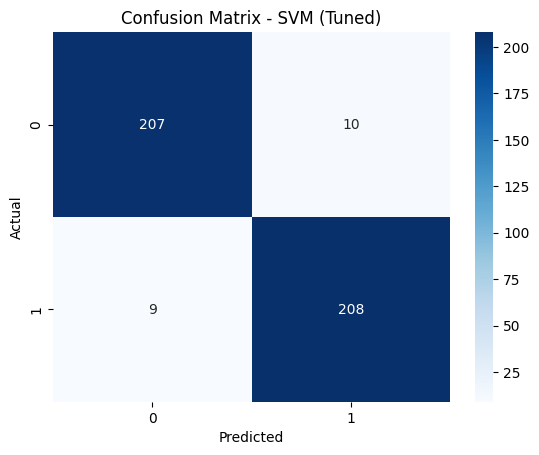

 Model 8 (Tuned SVM) trained, saved, and GUI-ready.


In [ ]:
# Support Vector Machine (Tuned)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Input
X = df['clean_text']
y = df['label']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Define pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', SVC(probability=True, random_state=42))
])

# Define parameter grid
param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__kernel': ['linear', 'rbf'],
    'clf__gamma': ['scale', 'auto']
}

# Grid Search
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)

# Train
start = time.time()
grid.fit(X_train, y_train)
end = time.time()
train_time = round(end - start, 2)

best_model = grid.best_estimator_
print(" Best Parameters Found:\n", grid.best_params_)

# Predict and evaluate
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
with open("model8_svm_tuned_pipeline.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Save results
results_df = pd.DataFrame({
    "Model": ["SVM_Tuned_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model8_svm_tuned_pipeline_results.csv", index=False)

print(" Model 8 (Tuned SVM) trained, saved, and GUI-ready.")

### **5-  XGBoost**

**Baseline  XGBoost**


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96       217
           1       0.97      0.95      0.96       217

    accuracy                           0.96       434
   macro avg       0.96      0.96      0.96       434
weighted avg       0.96      0.96      0.96       434



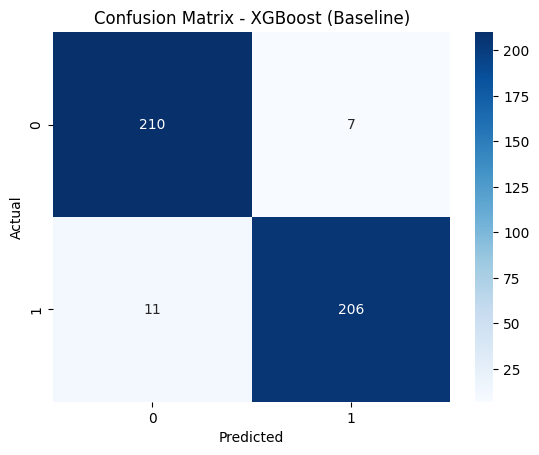

Model 9 (XGBoost Baseline)


In [ ]:
# XGBoost (Baseline)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Confirm structure
assert 'text' in df.columns, "Column 'text' not found."
assert 'label' in df.columns, "Column 'label' not found."

X = df['text']
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Build pipeline (TF-IDF + XGBoost)
pipeline_xgb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# Train model
start = time.time()
pipeline_xgb.fit(X_train, y_train, clf__sample_weight=sample_weights)
end = time.time()
train_time = round(end - start, 2)

# Predict & evaluate
y_pred = pipeline_xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
with open("model9_xgb_pipeline.pkl", "wb") as f:
    pickle.dump(pipeline_xgb, f)

# Save training results
results_df = pd.DataFrame({
    "Model": ["XGBoost_Baseline_Pipeline"],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model9_xgb_pipeline_results.csv", index=False)

print("Model 9 (XGBoost Baseline)")


**Tuned  XGBoost Model**

Fitting 3 folds for each of 8 candidates, totalling 24 fits
 Best Params: {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200}

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95       217
           1       0.97      0.94      0.95       217

    accuracy                           0.95       434
   macro avg       0.95      0.95      0.95       434
weighted avg       0.95      0.95      0.95       434



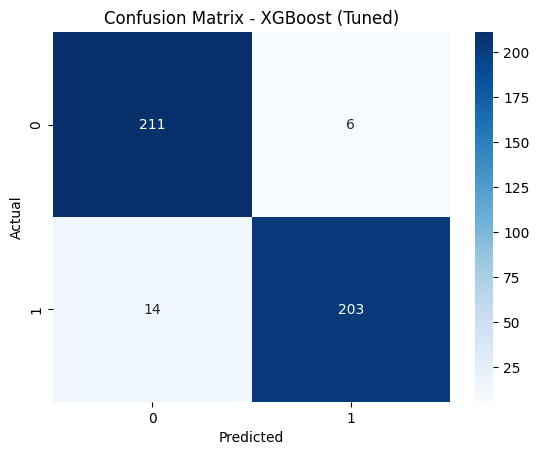

 Model 10 (XGBoost Tuned) 


In [ ]:
# XGBoost (Tuned)

import pandas as pd
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Confirm working input
assert 'text' in df.columns
assert 'label' in df.columns

X = df['text']
y = df['label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Compute sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

#  Define grid search
param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.1, 0.01]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

# Train with tuning
start = time.time()
grid.fit(X_train, y_train, clf__sample_weight=sample_weights)
end = time.time()
train_time = round(end - start, 2)

best_model = grid.best_estimator_
print(" Best Params:", grid.best_params_)

# Predict & evaluate
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Save model
with open("model10_xgb_tuned_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save results
results_df = pd.DataFrame({
    "Model": ["XGBoost_Tuned_Pipeline"],
    "Best_Params": [str(grid.best_params_)],
    "Accuracy": [acc],
    "F1_Score": [f1],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model10_xgb_tuned_pipeline_results.csv", index=False)

print(" Model 10 (XGBoost Tuned) ")

### **6- DistilBERT**

**DistilBERT Baseline**

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3: 100%|██████████| 109/109 [00:04<00:00, 24.59it/s]



=== Classification Report ===
                    precision    recall  f1-score   support

      Not Suicide       1.00      0.97      0.98       217
Potential Suicide       0.97      1.00      0.98       217

         accuracy                           0.98       434
        macro avg       0.98      0.98      0.98       434
     weighted avg       0.98      0.98      0.98       434



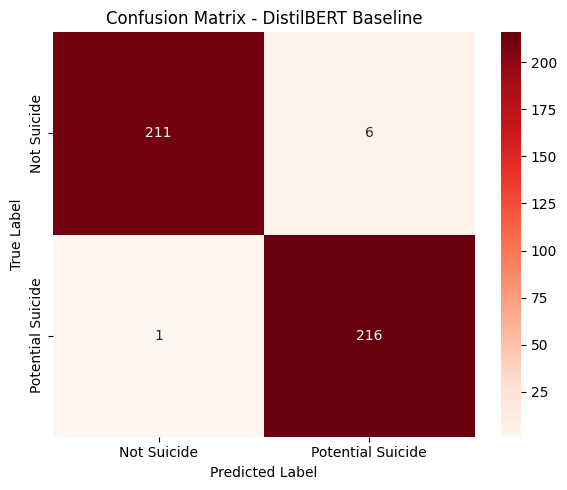

DistilBERT model and tokenizer saved to: model11_distilbert_baseline/


In [ ]:
# DistilBERT (Baseline)

import pandas as pd
import time
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm import tqdm

assert 'text' in df.columns
assert 'label' in df.columns

X = df['text'].tolist()
y = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Tokenization and Dataset Prep
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class SuicideDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = SuicideDataset(X_train, y_train, tokenizer)
test_dataset = SuicideDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

#  Load Model
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer and Scheduler
optimizer = AdamW(model.parameters(), lr=5e-5)
num_training_steps = len(train_loader) * 3
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

# Training Loop
model.train()
start = time.time()
for epoch in range(3):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
end = time.time()
train_time = round(end - start, 2)

# Evaluation
model.eval()
preds = []
true = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
        true.extend(batch["labels"].cpu().numpy())

acc = accuracy_score(true, preds)
report = classification_report(true, preds, target_names=['Not Suicide', 'Potential Suicide'])
print("\n=== Classification Report ===\n", report)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(true, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=['Not Suicide', 'Potential Suicide'], yticklabels=['Not Suicide', 'Potential Suicide'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DistilBERT Baseline")
plt.tight_layout()
plt.show()

# Save Model + Tokenizer Locally
save_path = "model11_distilbert_baseline/"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# Save Results
results_df = pd.DataFrame({
    "Model": ["DistilBERT_Baseline"],
    "Accuracy": [acc],
    "Train_Time_Sec": [train_time]
})
results_df.to_csv("model11_distilbert_baseline_results.csv", index=False)

print("DistilBERT model and tokenizer saved to:", save_path)


**Tuned DistilBERT Model Building**

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 3: 100%|██████████| 55/55 [00:06<00:00,  7.91it/s]



Classification Report:
                    precision    recall  f1-score   support

      Not Suicide       0.99      0.96      0.98       217
Potential Suicide       0.96      0.99      0.98       217

         accuracy                           0.98       434
        macro avg       0.98      0.98      0.98       434
     weighted avg       0.98      0.98      0.98       434



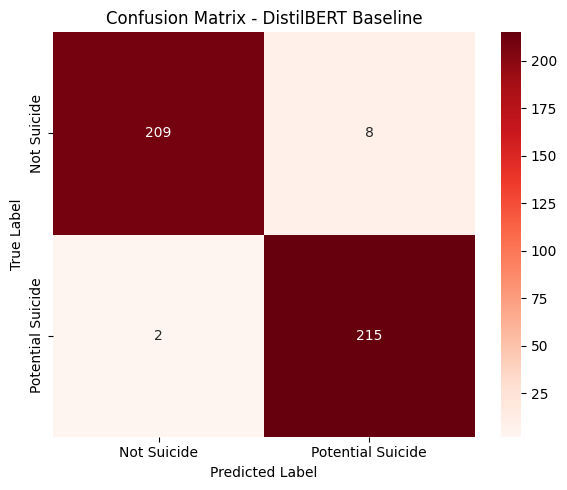

 Model 12 (DistilBERT Tuned) 


In [ ]:
# DistilBERT (Tuned)
import pandas as pd
import time
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_scheduler
from tqdm import tqdm

#  Input Check
assert 'text' in df.columns
assert 'label' in df.columns


X = df['text'].tolist()
y = df['label'].tolist()

#  Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

#  Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class SuicideDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

#  Tuning Grid
learning_rate = 2e-5
batch_size = 32
max_len = 256
epochs = 3

#  Loading dataset with selected max_len
train_dataset = SuicideDataset(X_train, y_train, tokenizer, max_len)
test_dataset = SuicideDataset(X_test, y_test, tokenizer, max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Load model
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer & Scheduler
optimizer = AdamW(model.parameters(), lr=learning_rate)
num_training_steps = len(train_loader) * epochs
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

#  Train loop
model.train()
start = time.time()
for epoch in range(epochs):
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
end = time.time()
train_time = round(end - start, 2)

#  Evaluation
model.eval()
preds = []
true = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
        true.extend(batch["labels"].cpu().numpy())

acc = accuracy_score(true, preds)
report = classification_report(true, preds, target_names=['Not Suicide', 'Potential Suicide'])
print("\nClassification Report:\n", report)

# Confusion Matrix
cm = confusion_matrix(true, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=['Not Suicide', 'Potential Suicide'], yticklabels=['Not Suicide', 'Potential Suicide'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - DistilBERT Baseline")
plt.tight_layout()
plt.show()

# Save model/tokenizer
model.save_pretrained("model12_distilbert_tuned/")
tokenizer.save_pretrained("model12_distilbert_tuned/")

#  Save results
results_df = pd.DataFrame({
    "Model": ["DistilBERT_Tuned"],
    "Accuracy": [acc],
    "Train_Time_Sec": [train_time],
    "Learning_Rate": [learning_rate],
    "Batch_Size": [batch_size],
    "Max_Length": [max_len]
})
results_df.to_csv("model12_distilbert_tuned_results.csv", index=False)

print(" Model 12 (DistilBERT Tuned) ")

## **Step 7: Model comparison**

In [ ]:
import pandas as pd
import glob
import shutil
import os

# Load all model result CSVs
csv_files = sorted(glob.glob("model*_results.csv"))

df_list = []
for file in csv_files:
    df = pd.read_csv(file)
    df['Result_File'] = file
    df = df.drop(columns=[col for col in ['Best_Params', 'Learning_Rate', 'Batch_Size', 'Max_Length'] if col in df.columns])
    df_list.append(df)

# Merge and sort
comparison_df = pd.concat(df_list, ignore_index=True)
sort_col = 'F1_Score' if 'F1_Score' in comparison_df.columns else 'Accuracy'
comparison_df = comparison_df.sort_values(by=sort_col, ascending=False).reset_index(drop=True)

# Identify best model
best_model_name = comparison_df.loc[0, 'Model']
print(" Best model identified from CSV:", best_model_name)

# Match to actual saved file or folder
model_file_lookup = {
    "RandomForest_Baseline_Pipeline": "model1_rf_pipeline.pkl",
    "RandomForest_Tuned_Pipeline": "model2_rf_tuned_pipeline.pkl",
    "LogisticRegression_Tuned_Pipeline": "model4_lr_tuned_pipeline.pkl",
    "NaiveBayes_Baseline_Pipeline": "model5_nb_pipeline.pkl",
    "NaiveBayes_Tuned_Pipeline": "model6_nb_tuned_pipeline.pkl",
    "SVM_Baseline_Pipeline": "model7_svm_pipeline.pkl",
    "SVM_Tuned_Pipeline": "model8_svm_tuned_pipeline.pkl",
    "XGBoost_Baseline_Pipeline": "model9_xgb_pipeline.pkl",
    "XGBoost_Tuned_Pipeline": "model10_xgb_tuned_pipeline.pkl",
    "DistilBERT_Baseline": "model11_distilbert_baseline/",
    "DistilBERT_Tuned": "model12_distilbert_tuned/"
}

found_model_file = model_file_lookup.get(best_model_name)

# Save the best model for GUI
if found_model_file:
    if os.path.isdir(found_model_file):
        if os.path.exists("best_model"):
            shutil.rmtree("best_model")
        shutil.copytree(found_model_file, "best_model")
        print(f" Copied model folder to: best_model/ from {found_model_file}")
    elif os.path.isfile(found_model_file):
        shutil.copy(found_model_file, "best_model.pkl")
        print(f" Copied model file to: best_model.pkl from {found_model_file}")
    else:
        print(f" File or folder not found: {found_model_file}")
else:
    print(" No mapping found for best model:", best_model_name)

# Show the full sorted table
print(" 12-Model Performance Comparison:")
display(comparison_df)

# Save summary
comparison_df.to_csv("all_models_comparison_summary.csv", index=False)

 Best model identified from CSV: DistilBERT_Baseline
 Copied model folder to: best_model/ from model11_distilbert_baseline/
 12-Model Performance Comparison:


,Model,Accuracy,F1_Score,Train_Time_Sec,Result_File
0,DistilBERT_Baseline,0.986175,0.986175,52.02,model11_distilbert_baseline_results.csv
1,DistilBERT_Tuned,0.970046,0.970046,93.48,model12_distilbert_tuned_results.csv
2,XGBoost_Baseline_Pipeline,0.958525,0.958522,1.15,model9_xgb_pipeline_results.csv
3,SVM_Tuned_Pipeline,0.956221,0.956221,33.44,model8_svm_tuned_pipeline_results.csv
4,RandomForest_Tuned_Pipeline,0.956221,0.956219,62.18,model2_rf_tuned_pipeline_results.csv
5,RandomForest_Baseline_Pipeline,0.956221,0.956210,1.21,model1_rf_pipeline_results.csv
6,XGBoost_Tuned_Pipeline,0.953917,0.953901,25.41,model10_xgb_tuned_pipeline_results.csv
7,LogisticRegression_Tuned_Pipeline,0.940092,0.940087,1.99,model4_lr_tuned_pipeline_results.csv
8,SVM_Baseline_Pipeline,0.930876,0.930874,1.81,model7_svm_pipeline_results.csv
9,LogisticRegression_Baseline_Pipeline,0.928571,0.928568,0.27,model3_lr_pipeline_results.csv


## **Step 8: GUI**

In [ ]:
!pip install -q spacy
!python -m spacy download en_core_web_sm

import spacy
nlp = spacy.load("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 124.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# NSTALLATION
!pip install -q gradio transformers torch language_tool_python

# IMPORTS
import gradio as gr
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import language_tool_python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.0 MB/s eta 0:00:00


In [ ]:
# Upgrade Java to version 17
!apt update -q
!apt install -y openjdk-17-jdk
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,776 kB]
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,037 kB]
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,750 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,986 kB]
Hit:12 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.c

In [ ]:
import language_tool_python
tool = language_tool_python.LanguageTool('en-US')

INFO:language_tool_python.download_lt:Unzipping /tmp/tmphraq3hml.zip to /root/.cache/language_tool_python.
INFO:language_tool_python.download_lt:Downloaded https://internal1.languagetool.org/snapshots/LanguageTool-latest-snapshot.zip to /root/.cache/language_tool_python.


In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [ ]:
# SPELLING TOOL
def correct_text(text):
    matches = tool.check(text)
    return language_tool_python.utils.correct(text, matches)

# NLP MODEL FOR RULE FILTER
import spacy
nlp = spacy.load("en_core_web_sm")

# LOAD BEST MODEL (DistilBERT Baseline)
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch

model_path = "model11_distilbert_baseline"
model = DistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# RULE-BASED GUARDRAILS
def is_false_positive(text):
    whitelist = [
        "kill a chicken", "kill the engine", "kill a bug", "kill time",
        "kill the lights", "kill the mood", "kill weeds", "kill pests",
        "kill a program"
    ]
    text_lower = text.lower()
    return any(phrase in text_lower for phrase in whitelist)

def is_aggression_not_suicide(text):
    aggression_patterns = [
        "kill him", "kill her", "kill them", "shoot him", "stab her",
        "i will kill you", "kill the president", "murder them", "attack him"
    ]
    text_lower = text.lower()
    return any(phrase in text_lower for phrase in aggression_patterns)

def is_violence_directed_at_others(text):
    doc = nlp(text.lower())
    for token in doc:
        if token.lemma_ == "kill" and token.dep_ == "ROOT":
            for child in token.children:
                if child.dep_ in ("dobj", "nsubj", "nmod") and child.text in ["him", "her", "them", "man", "woman", "enemy", "guy"]:
                    return True
    return False

# PREDICTION FUNCTION
def predict(text):
    corrected = correct_text(text)

    # Apply rule-based filters
    if is_false_positive(corrected) or is_aggression_not_suicide(corrected) or is_violence_directed_at_others(corrected):
        return "Not Suicide", "0.0000", corrected

    inputs = tokenizer(corrected, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1).cpu().flatten()

    confidence = float(probs[1])
    label = "Suicide Risk" if confidence > 0.7 else "Not Suicide"
    return label, f"{confidence:.4f}", corrected

In [ ]:
# GRADIO INTERFACE
interface = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(label="Enter a Tweet or Short Message", lines=4, placeholder="e.g., I can't do this anymore..."),
    outputs=[
        gr.Label(label="Prediction"),
        gr.Label(label="Confidence Score (Suicide Class)"),
        gr.Textbox(label="Corrected Message")
    ],
    title="Suicide Ideation Detection",
    description="This tool detects suicidal intent from text messages using the best-performing DistilBERT model. It also corrects spelling and grammar before prediction.",
    allow_flagging="never",
    theme="default"
)

# LAUNCH the GUI
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6ab5f1de84ae5fdcf1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
